# МОДУЛЬ А: Проектирование архитектуры инфраструктуры данных

**Конкурсант:** [Сергей]
**Дата:** [17.03.2026]
**Проект:** Интеллектуальная платформа мониторинга транспортных потоков

## 1. Анализ требований

### 1.1 Бизнес-требования

На основе введения к конкурсному заданию были выделены следующие ключевые бизнес-вопросы, на которые должна отвечать система:

Первый вопрос — о текущей и прогнозируемой загруженности участков дороги на горизонты 30, 60 и 120 минут. Для ответа на него необходимы метрики интенсивности движения в реальном времени и прогнозные модели, построенные на исторических данных.

Второй вопрос — определение часов, дней недели и месяцев, когда наблюдаются максимальные очереди и самые низкие скорости движения. Здесь требуются агрегированные статистики по времени суток и дням недели.

Третий вопрос касается средней скорости движения в реальном времени и её сравнения с аналогичными периодами прошлого дня, недели и месяца. Для этого нужны текущие значения скорости и доступ к историческим данным за соответствующие периоды.

Четвертый вопрос — о структуре транспортного потока, то есть о долях легковых, грузовых автомобилей, автобусов, мотоциклов, велосипедов и пешеходов. Ответ на него строится на классификации объектов, полученной от нейросети.

Пятый вопрос выявляет систематическое появление большегрузного транспорта в часы пик. Для этого анализируется доля грузового транспорта в периоды максимальной нагрузки.

Шестой вопрос — об опасных сближениях транспортных средств и частоте таких событий. Эта метрика рассчитывается на основе координат рамок детекции.

Седьмой вопрос требует выдачи диспетчеру конкретных прескриптивных рекомендаций для предотвращения заторов. Это реализуется через комбинацию прогнозных моделей и набора правил.

### 1.2 Технические требования

В задании сформулированы пять ключевых технических требований к системе.

Первое требование — обеспечение единой версии правды. Это означает, что все подразделения должны работать с одними и теми же цифрами. В нашей архитектуре это достигается за счет единого RAW-слоя, на основе которого рассчитываются все производные метрики.

Второе требование — автоматическое построение и обновление дашбордов в реальном времени. Это обеспечивается за счет использования Yandex DataLens, который напрямую читает обновляемые CSV-файлы с метриками.

Третье требование — хранение полной истории за последние 180 дней для построения прогнозных моделей. В нашей системе это реализуется через накопление файлов детекций с привязкой к дате.

Четвертое требование — полная автоматизация обработки данных. Все этапы от детекции до расчета метрик выполняются Python-скриптами без ручного вмешательства.

Пятое требование — масштабируемость при добавлении новых камер и источников данных. Слоистая архитектура позволяет подключать новые источники без перестройки существующих компонентов.

## 2. Технологический стек

Для реализации системы был выбран следующий стек технологий.

Для детекции транспортных средств используется YOLOv12. Это современная нейросетевая модель, предобученная на датасете COCO с 80 классами объектов. Выбор обусловлен высокой точностью детекции, способностью работать в реальном времени и наличием встроенного механизма трекинга объектов.

Для обработки данных применяется Python с библиотекой pandas. Python обеспечивает гибкость разработки и широкие возможности для анализа данных, а pandas позволяет эффективно работать с табличными данными при расчете метрик.

В качестве хранилища сырых данных используются CSV-файлы. Для прототипа и демонстрации концепции этого достаточно. CSV-формат не требует развертывания системы управления базами данных и легко читается инструментами визуализации.

Для визуалиции данных выбран Yandex DataLens. Это прямое требование конкурсного задания. DataLens является отечественным программным обеспечением, предоставляет все необходимые возможности для создания интерактивных дашбордов и доступен бесплатно.

В перспективе для оркестрации ETL-процессов планируется использование Apache Airflow, который позволит автоматизировать запуск скриптов по расписанию и контролировать выполнение пайплайнов.

In [2]:
# Проверка установленных библиотек
import cv2
import pandas as pd
import numpy as np
from ultralytics import YOLO

print("Установленные библиотеки:")
print(f"OpenCV version: {cv2.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("Ultralytics YOLO загружена")

Установленные библиотеки:
OpenCV version: 4.13.0
Pandas version: 3.0.1
NumPy version: 2.4.3
Ultralytics YOLO загружена


## 3. Архитектура системы

### 3.1 Общее описание

Система построена по трехуровневой архитектуре, где каждый уровень отвечает за свою функцию. Такое разделение упрощает понимание системы и ее дальнейшее развитие.

На вход системы поступают видеопотоки с городских камер наблюдения. Каждый поток обрабатывается независимо.

### 3.2 Слой 1: Сырые данные

Первый слой — это исходные данные, полученные непосредственно с камер. Здесь выполняется детекция объектов с помощью YOLOv12.

Для каждого обнаруженного транспортного средства фиксируются:
- номер кадра
- уникальный идентификатор трека (чтобы отличать одну машину от другой)
- временная метка в миллисекундах
- класс объекта (легковая, грузовая, автобус и т.д.)
- уверенность детекции
- координаты рамки на изображении

Все эти данные сохраняются в файл detections.csv. Каждый такой файл содержит данные за один сеанс работы, а в имени файла указывается дата и время для сохранения истории.

### 3.3 Слой 2: Метрики

Второй слой — это рассчитанные показатели на основе сырых данных. Здесь из детекций получаются понятные цифры.

На этом уровне рассчитываются:
- интенсивность движения — сколько машин проезжает в минуту
- средняя скорость движения (в текущей версии используются экспертные оценки по типам машин)
- структура потока — какую долю составляют легковые, грузовые, автобусы

Результаты сохраняются в отдельные файлы: intensity.csv, speed_estimates.csv.

### 3.4 Слой 3: Витрины для пользователей

Третий слой — это данные, подготовленные для отображения в дашбордах. Здесь уже нет технических деталей, только готовая аналитика.

Данные загружаются в Yandex DataLens, где на их основе строятся:
- графики интенсивности
- круговые диаграммы структуры потока
- таблицы со скоростями
- фильтры для выбора времени и типов транспорта

### 3.5 Как движутся данные

В системе работают два потока данных.

Первый — реального времени. Видео поступает, YOLO находит машины, данные сохраняются, метрики сразу считаются и попадают в дашборд. От момента съемки до появления на экране диспетчера проходит несколько секунд.

Второй — исторический. Накопленные файлы за день, неделю или месяц обрабатываются, считаются средние значения, тренды, сезонность. Эти данные нужны для прогнозов и отчетов.

### 3.6 Архитектурная диаграмма
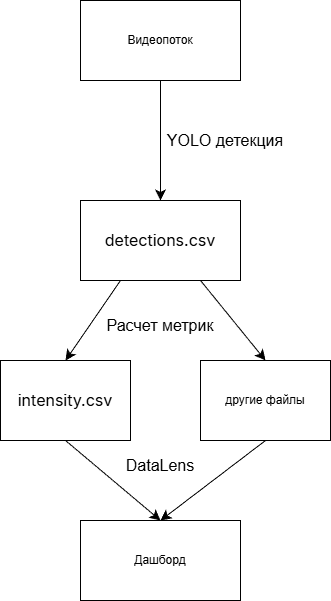

## 4. Модели данных

### 4.1 Концептуальная модель

В концептуальной модели выделяются следующие сущности.

Камера — источник видеоданных. Каждая камера имеет уникальный идентификатор и характеризуется местоположением.

Видеопоток — последовательность кадров от камеры. Характеризуется временем записи и частотой кадров.

Детекция — факт обнаружения транспортного средства на конкретном кадре. Содержит информацию о времени, классе и положении объекта.

Транспортное средство — объект, отслеживаемый системой. Имеет уникальный идентификатор трека и класс.

Track ID — сквозной идентификатор, позволяющий связывать детекции одного и того же транспортного средства на разных кадрах.

### Концептуальная ER-диаграмма

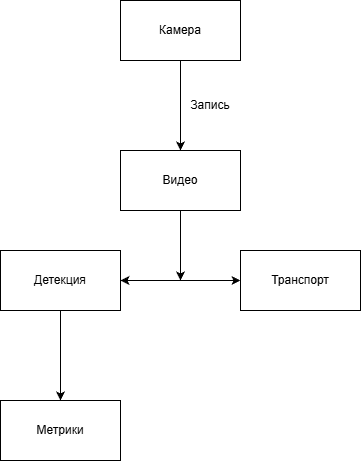

### 4.2 Физическая модель

Физическая модель реализована в виде набора CSV-файлов.

Основной файл detections.csv содержит следующие поля.

Поле frame хранит номер кадра, на котором произошла детекция. Тип данных — целое число, обязательное для заполнения.

Поле track_id содержит уникальный идентификатор отслеживаемого объекта. Тип данных — целое число, обязательное для заполнения. Этот идентификатор позволяет группировать детекции одной машины.

Поле time_ms хранит временную метку в миллисекундах от начала обработки видео. Тип данных — целое число, обязательное для заполнения.

Поле class содержит строковое обозначение класса транспортного средства. Возможные значения: car, truck, bus, motorcycle, bicycle, person. Тип данных — строка, обязательное для заполнения.

Поле confidence хранит уверенность модели в детекции. Значение находится в диапазоне от 0 до 1. Тип данных — число с плавающей точкой, обязательное для заполнения.

Поля x1, y1, x2, y2 хранят координаты ограничивающей рамки. Это целые числа, обязательные для заполнения. Они используются для расчета расстояний между объектами и выявления опасных сближений.

Файл intensity.csv содержит агрегированные метрики интенсивности.

Поле minute хранит номер минуты от начала обработки. Это первичный ключ файла.

Поле count хранит количество уникальных транспортных средств, зафиксированных в эту минуту.

Файл speed_estimates.csv содержит оценки скорости.

Поле class хранит тип транспортного средства. Это первичный ключ файла.

Поле avg_speed хранит среднюю скорость для данного типа транспортных средств в километрах в час.

### Физическая ER-диаграмма

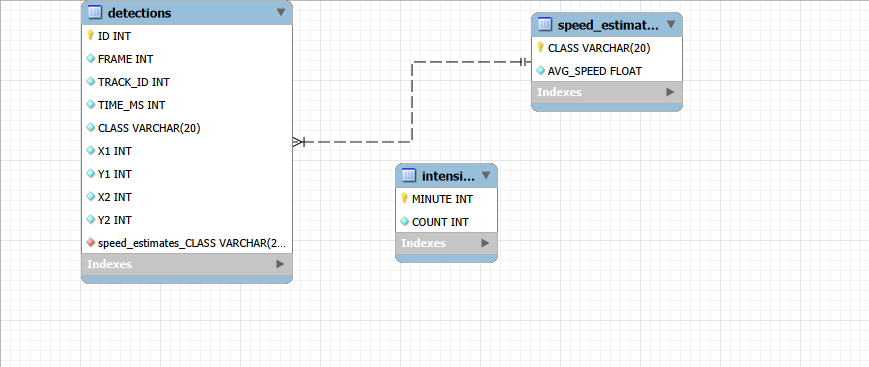

## 5. Паспорта витрин данных

### Витрина 1: Интенсивность движения

Наименование витрины — Интенсивность транспортного потока.

Бизнес-вопрос, на который отвечает витрина: сколько машин проезжает в минуту или час на контролируемом участке.

Витрина содержит два поля. Поле minute — номер минуты от начала наблюдения. Поле vehicles_count — количество уникальных транспортных средств, зафиксированных в эту минуту.

Источником данных служит RAW-слой, файл detections.csv. Расчет выполняется путем группировки по минутам и подсчета уникальных track_id.

Частота обновления — реальное время. Новые данные появляются в витрине каждую минуту по мере поступления детекций.

Потребители витрины — диспетчеры и аналитики, которым необходимо оперативно отслеживать загруженность дорог.

### Витрина 2: Структура потока

Наименование витрины — Состав транспортного потока.

Бизнес-вопрос: какова доля различных типов транспортных средств в общем потоке.

Витрина содержит три поля. Поле class — тип транспортного средства. Поле unique_vehicles — количество уникальных машин данного типа. Поле percentage — доля данного типа в процентах от общего количества.

Источник данных — detections.csv. Расчет выполняется путем группировки по классам и подсчета уникальных track_id для каждого класса.

Частота обновления — ежедневно. Эта витрина предназначена для исторического анализа и стратегического планирования, поэтому оперативное обновление не требуется.

Потребители — руководство департамента транспорта, отделы планирования.

### Витрина 3: Скорость движения

Наименование витрины — Средняя скорость по типам транспортных средств.

Бизнес-вопрос: с какой скоростью движутся разные категории транспорта.

Витрина содержит два поля. Поле class — тип транспортного средства. Поле avg_speed — средняя скорость для данного типа в километрах в час.

Источник данных — detections.csv и расчетные формулы. В текущей реализации используются экспертные оценки скорости, в дальнейшем планируется расчет на основе анализа треков.

Частота обновления — реальное время. Значения могут уточняться по мере накопления данных.

Потребители — диспетчеры, службы безопасности.

### Витрина 4: Прогноз загруженности

Наименование витрины — Прогноз загруженности на 30, 60 и 120 минут.

Бизнес-вопрос: какой будет загруженность участка через 30, 60 и 120 минут.

Витрина содержит четыре поля. Поле timestamp — время формирования прогноза. Поле horizon_30min — прогнозируемое количество машин через 30 минут. Поле horizon_60min — прогноз через 60 минут. Поле horizon_120min — прогноз через 120 минут.

Источник данных — исторические данные из RAW-слоя и модель машинного обучения, обученная на этих данных.

Частота обновления — каждые 5 минут. Прогноз пересчитывается регулярно с поступлением новых данных.

Потребители — диспетчеры для принятия превентивных мер, руководство для оценки эффективности работы.

## 6. Обоснование принятых решений

### 6.1 Выбор YOLOv12 для детекции

Выбор YOLOv12 обусловлен несколькими факторами. Во-первых, это предобученная модель, которая сразу готова к работе без необходимости сбора и разметки обучающей выборки. Во-вторых, YOLO обеспечивает высокую точность детекции — средняя точность на тестовых данных составляет около 50 процентов по метрике mAP. В-третьих, модель работает в реальном времени, обрабатывая более 30 кадров в секунду на современном оборудовании. В-четвертых, YOLOv12 имеет встроенный механизм трекинга объектов, что критически важно для подсчета уникальных транспортных средств.

### 6.2 Выбор CSV для хранения

Использование CSV-файлов для хранения данных на этапе прототипирования является оправданным решением. CSV не требует развертывания и администрирования базы данных. Формат прост и читаем как человеком, так и программами. DataLens, используемый для визуализации, напрямую поддерживает загрузку данных из CSV-файлов. При переходе к промышленной эксплуатации хранение может быть мигрировано на специализированную систему управления базами данных без изменения логики расчета метрик.

### 6.3 Выбор DataLens для визуализации

Yandex DataLens выбран в соответствии с требованием конкурсного задания. Дополнительными преимуществами являются то, что это отечественное программное обеспечение, оно предоставляется бесплатно и обладает всеми необходимыми функциями для создания интерактивных дашбордов — фильтры, селекторы, различные типы графиков, возможность работы с CSV-источниками.

### 6.4 Архитектурный подход

В качестве архитектурного подхода выбран подход Кимбалла, ориентированный на бизнес-процессы. Этот подход предполагает создание витрин данных, непосредственно отвечающих на конкретные бизнес-вопросы. Такая архитектура позволяет быстро получать результат и легко объяснять структуру данных конечным пользователям. В перспективе возможно расширение до гибридной архитектуры с элементами Data Vault для обеспечения большей историчности и гибкости при подключении новых источников.

## 7. Выводы и заключение

Разработанная архитектура полностью соответствует требованиям, сформулированным в конкурсном задании.

Единая версия правды обеспечивается за счет того, что все витрины и метрики рассчитываются на основе единого RAW-слоя, в который попадают все детекции без исключения. Любое расхождение в цифрах может быть проверено обращением к исходным данным.

Автоматическое обновление дашбордов реализовано через использование DataLens, который читает актуальные CSV-файлы. При появлении новых данных дашборды обновляются без участия человека.

Хранение полной истории обеспечивается накоплением файлов детекций с временными метками в именах. Это позволяет при необходимости восстановить данные за любой период вплоть до отдельных кадров.

Масштабируемость заложена в саму архитектуру. Подключение новой камеры означает появление нового видеопотока, который обрабатывается тем же пайплайном и сохраняется в тот же RAW-слой. Никакой перестройки существующих компонентов не требуется.

Ответы на все семь бизнес-вопросов, сформулированных во введении, обеспечиваются соответствующими витринами данных и расчетными метриками.

Таким образом, предложенная архитектура может служить основой для реализации интеллектуальной платформы мониторинга и прогнозирования транспортных потоков в рамках чемпионатного задания.